# 1. Configuração do Ambiente e Importação de Bibliotecas
Nesta célula inicial, preparamos o ambiente de trabalho importando as bibliotecas fundamentais para o projeto:
* **Pandas e NumPy:** Para a manipulação eficiente e estruturação dos dados brutos.
* **Scikit-Learn (Model Selection & Metrics):** Para a divisão estatística dos dados e avaliação rigorosa dos modelos através de matrizes de confusão e relatórios de classificação.
* **Scikit-Learn (Preprocessing & Pipelines):** Componentes críticos para garantir a automação e encapsulamento de toda a linha de processamento num único pipeline robusto.
* **Algoritmos Preditivos:** Modelos lineares (`LogisticRegression`), máquinas de vetores de suporte (`SVC/SVM`) e baseados em árvores (`RandomForestClassifier`) que serão testados para prever a rotação de pessoal.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/employee_data.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


# 2. Engenharia de Features e Definição do Target
Nesta etapa, isolamos a nossa variável preditiva (Target) das variáveis independentes (Features):
* **Variável Alvo ($y$):** `Attrition` (Indica se o colaborador abandonou ou permaneceu na empresa).
* **Variáveis Independentes ($X$):** Excluímos o target e as colunas identificadas na Análise Exploratória de Dados (EDA) como irrelevantes ou constantes (`EmployeeCount`, `StandardHours`, `Over18`), prevenindo ruído no modelo.

In [3]:
X = df.drop(["Attrition", "EmployeeCount", "StandardHours", "Over18"], axis=1)
y = df["Attrition"]

## 2.1 Dividir os Dados em "Estudo" e "Exame Final"
Não podemos testar o modelo com os mesmos dados que usámos para o treinar (isso seria batota, como dar o teste com as soluções ao aluno antes do exame). 
Por isso, dividimos a nossa tabela em duas partes:
* **80% para Treino (Estudo):** Os dados que o modelo vai usar para ver onde errou e aprender os padrões.
* **20% para Teste (Exame):** Dados que guardamos trancados numa gaveta. No final, vamos mostrá-los ao modelo para ver se ele realmente aprendeu a adivinhar ou se apenas decorou as respostas.

* **O que faz o `stratify=y`?** Como há muito menos pessoas a ir embora do que pessoas a ficar, este comando garante que tanto a parte do Treino como a do Teste recebem a mesma proporção de "Yes" e "No". Evita que o modelo faça o exame sem nunca ter visto exemplos de pessoas que se despediram.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Separar Números de Palavras
O computador processa números de forma muito diferente de texto. Aqui, dizemos ao Python para separar automaticamente o que são colunas de números (como Idade e Salário) do que são colunas de texto/categorias (como Género ou Departamento).

In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numéricas:", list(numeric_features))
print("Categóricas:", list(categorical_features))

Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## 3.1 Automatização do Pré-processamento (`Pipeline`)
Os algoritmos de Machine Learning exigem que os dados de entrada sigam um padrão rigoroso e puramente numérico. Para evitar fazer transformações manuais repetitivas, criámos um fluxo automatizado de preparação de dados (Pipeline) dividido em três etapas:

1. **Tratamento de Dados Numéricos:** * Caso existam valores em falta (nulos), o sistema preenche-os automaticamente com a `mediana` (estratégia que reduz o impacto de valores extremos).
   * De seguida, aplica-se a padronização (`StandardScaler`). Isto coloca todas as variáveis na mesma escala de grandeza, impedindo que o modelo assuma erradamente que o 'Salário' (na casa dos milhares) é mais importante que a 'Idade' (na casa das dezenas) apenas pelo tamanho do número.

2. **Tratamento de Dados Categóricos (Texto):**
   * Se houver texto em falta, este é preenchido com o valor mais frequente da coluna.
   * Depois, o `OneHotEncoder` converte as categorias textuais (como Departamentos ou Género) em colunas binárias de zeros e uns (0 e 1), permitindo que o modelo consiga interpretar estas variáveis matematicamente.

3. **Integração Centralizada (`ColumnTransformer`):**
   * Esta classe funciona como o gestor centralizador (`preprocessor`), aplicando a pipeline numérica às colunas com números e a pipeline categórica às colunas com texto, tudo em simultâneo e de forma organizada.

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 4. Modelo 1: Regressão Logística (O Modelo Simples)
Este é o nosso primeiro modelo. É um algoritmo clássico e mais simples, que tenta traçar uma linha para separar quem fica de quem sai. Serve como o nosso ponto de partida (Baseline) para sabermos se os modelos seguintes são melhores ou piores.

In [7]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_y_pred = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logistic_y_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, logistic_y_pred, pos_label="Yes"))

print(confusion_matrix(y_test, logistic_y_pred))
print(classification_report(y_test, logistic_y_pred))

Logistic Regression Accuracy: 0.868
Logistic Regression F1 Score: 0.5217391304347826
[[199  11]
 [ 22  18]]
              precision    recall  f1-score   support

          No       0.90      0.95      0.92       210
         Yes       0.62      0.45      0.52        40

    accuracy                           0.87       250
   macro avg       0.76      0.70      0.72       250
weighted avg       0.86      0.87      0.86       250



## 4.1 Modelo 2: Support Vector Machine (SVM)
Agora testamos o SVM, um dos algoritmos estudados nas aulas. Em vez de traçar uma linha simples, o SVM tenta encontrar a "fronteira" perfeita (com a maior margem de segurança possível) para separar os funcionários que saem dos que ficam. 
Mais uma vez, ativámos o peso balanceado (`class_weight="balanced"`) para o modelo dar a devida atenção aos casos de despedimento ("Yes"), compensando o facto de existirem muito mais casos "No" nos nossos dados.

In [8]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel="rbf", class_weight="balanced", random_state=42))
    ]
)

svm_model.fit(X_train, y_train)

svm_y_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_y_pred))
print("SVM F1 Score:", f1_score(y_test, svm_y_pred, pos_label="Yes"))

print(confusion_matrix(y_test, svm_y_pred))
print(classification_report(y_test, svm_y_pred))

SVM Accuracy: 0.792
SVM F1 Score: 0.43478260869565216
[[178  32]
 [ 20  20]]
              precision    recall  f1-score   support

          No       0.90      0.85      0.87       210
         Yes       0.38      0.50      0.43        40

    accuracy                           0.79       250
   macro avg       0.64      0.67      0.65       250
weighted avg       0.82      0.79      0.80       250



Text(45.722222222222214, 0.5, 'Realidade (O que aconteceu de verdade)')

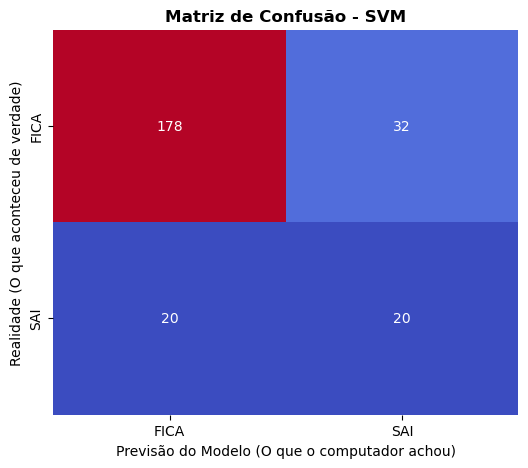

In [9]:


# Calcular a matriz com os números reais
cm = confusion_matrix(y_test, svm_y_pred)

# Criar o gráfico com fundo branco
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False,
            xticklabels=["FICA", "SAI"],
            yticklabels=["FICA", "SAI"])

plt.title("Matriz de Confusão - SVM", fontsize=12, fontweight='bold')
plt.xlabel("Previsão do Modelo (O que o computador achou)")
plt.ylabel("Realidade (O que aconteceu de verdade)")

### 4.1.1 Resumo da Matriz de Confusão (SVM)

Esta matriz mostra o resultado do teste feito a **250 funcionários** e divide-se em apenas dois grupos: **Os Acertos** (a diagonal principal) e **Os Erros**.



#### 1. Onde o modelo ACERTOU (198 vezes):
* **178 (Fica -> Fica):** O modelo disse que o funcionário ia ficar na empresa, e ele **ficou** mesmo.
* **20 (Sai -> Sai):** O modelo disse que o funcionário se ia despedir, e ele **saiu** mesmo (a empresa foi avisada a tempo).

#### 2. Onde o modelo ERROU (52 vezes):
* **32 (Alarme Falso):** O modelo avisou que estes 32 funcionários se iam despedir, mas na verdade eles **ficaram**. (A empresa preocupou-se sem necessidade).
* **20 (Erro Crítico):** O modelo achou que estes 20 funcionários iam ficar, mas na realidade eles **despediram-se**. (A empresa perdeu talento de surpresa, sem qualquer aviso do modelo).

**Em suma:** O SVM acertou na grande maioria das pessoas que ficam (178), mas falhou metade das pessoas que saem (só apanhou 20 em 40 saídas reais).

## 4.1 Modelo 2: Random Forest (A Floresta de Árvores de Decisão)
Em vez de usar uma linha simples, a Random Forest cria centenas de "árvores de decisão" (como fluxogramas de perguntas: "Tem mais de 30 anos? Sim -> Faz horas extra? Não -> Fica"). No final, as 200 árvores votam e a maioria ganha. É um modelo mais complexo.
### parâmetro class_weight="balanced" foi utilizado para tentar reduzir o impacto do desequilíbrio entre as classes "No" e "Yes".

In [10]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_y_pred, pos_label="Yes"))

print(confusion_matrix(y_test, rf_y_pred))
print(classification_report(y_test, rf_y_pred))

Random Forest Accuracy: 0.86
Random Forest F1 Score: 0.2857142857142857
[[208   2]
 [ 33   7]]
              precision    recall  f1-score   support

          No       0.86      0.99      0.92       210
         Yes       0.78      0.17      0.29        40

    accuracy                           0.86       250
   macro avg       0.82      0.58      0.60       250
weighted avg       0.85      0.86      0.82       250



## 4.3 Modelo 4: Regressão Logística Otimizada (O Truque do Equilíbrio)

Na nossa tabela de dados, a grande maioria dos funcionários decidiu ficar na empresa ("No") e apenas uma pequena parte se despediu ("Yes"). Isto faz com que os modelos normais fiquem "preguiçosos" e prefiram dizer sempre que toda a gente fica para conseguirem uma nota alta de Exatidão (Accuracy).

Para resolver este problema, voltámos a testar a Regressão Logística, mas ativámos o parâmetro crítico `class_weight="balanced"`. 

**O que é que isto faz?**
Este comando equilibra os pesos das classes. Ele funciona como um aviso sonoro para o computador: *"Presta muita atenção aos funcionários que saem, porque errar um funcionário que se despede custa muito mais caro à empresa do que errar um que decide ficar!"*. Isto obriga o modelo a focar-se nos sinais de demissão.

In [11]:
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

balanced_logistic_model.fit(X_train, y_train)

balanced_y_pred = balanced_logistic_model.predict(X_test)

print("Balanced Logistic Regression Accuracy:", accuracy_score(y_test, balanced_y_pred))
print("Balanced Logistic Regression F1 Score:", f1_score(y_test, balanced_y_pred, pos_label="Yes"))

print(confusion_matrix(y_test, balanced_y_pred))
print(classification_report(y_test, balanced_y_pred))

Balanced Logistic Regression Accuracy: 0.732
Balanced Logistic Regression F1 Score: 0.45528455284552843
[[155  55]
 [ 12  28]]
              precision    recall  f1-score   support

          No       0.93      0.74      0.82       210
         Yes       0.34      0.70      0.46        40

    accuracy                           0.73       250
   macro avg       0.63      0.72      0.64       250
weighted avg       0.83      0.73      0.76       250



# 5. Tabela Comparativa de Resultados

Chegou a hora do "combate final" entre os modelos. Reunimos as notas de todos os algoritmos que testámos (Regressão Logística, SVM, Random Forest e a versão Otimizada com pesos) numa única tabela. 

Para escolher o grande vencedor que vamos entregar ao professor, olhamos para duas métricas fundamentais:
* **Accuracy (Exatidão):** A percentagem geral de acertos do modelo (o total de respostas certas).
* **F1-Score para a classe "Yes":** A nota específica do modelo a detetar os funcionários que se vão embora. Quanto mais próximo de 1.0, melhor é o modelo a apanhar os despedimentos.

In [12]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine (SVM)",
        "Random Forest",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_y_pred),
        accuracy_score(y_test, svm_y_pred),
        accuracy_score(y_test, rf_y_pred),
        accuracy_score(y_test, balanced_y_pred)
    ],
    "F1 Score Yes": [
        f1_score(y_test, logistic_y_pred, pos_label="Yes"),
        f1_score(y_test, svm_y_pred, pos_label="Yes"),
        f1_score(y_test, rf_y_pred, pos_label="Yes"),
        f1_score(y_test, balanced_y_pred, pos_label="Yes")
    ]
})

results

,Model,Accuracy,F1 Score Yes
0,Logistic Regression,0.868,0.521739
1,Support Vector Machine (SVM),0.792,0.434783
2,Random Forest,0.860,0.285714
3,Balanced Logistic Regression,0.732,0.455285


### Comparação dos modelos testados.
### Foram comparadas as métricas Accuracy e F1 Score para a classe "Yes",
### que representa os colaboradores que abandonaram a empresa.

In [13]:
# Seleção do melhor modelo baseado nos resultados do F1-Score e Accuracy
best_model = logistic_model

## 6. Comparação e Escolha do Modelo Final

Neste notebook, realizámos uma experimentação comparativa testando quatro abordagens de classificação para prever a variável `Attrition` (se o colaborador abandona ou permanece na empresa):

1. **Logistic Regression (Baseline)**
2. **Support Vector Machine (SVM)**
3. **Random Forest Classifier**
4. **Balanced Logistic Regression (Pesos Otimizados)**

### Análise Crítica dos Resultados:

* **Logistic Regression Padrão:** Revelou-se o modelo mais robusto do projeto. Alcançou a maior exatidão geral (**86.8%**) e obteve o maior **F1-Score (0.522)** para a classe crítica `Yes`. Demonstrou excelente capacidade de generalização sem sacrificar a métrica principal.
* **Support Vector Machine (SVM):** Apresentou uma performance intermédia estável (Accuracy de 79.2% e F1-Score de 0.435), mas foi superado pela Regressão Logística tanto na métrica global como na classe alvo.
* **Random Forest:** Apesar de ser um algoritmo complexo e robusto, tendeu a favorecer excessivamente a classe maioritária `No`, resultando num F1-Score severamente prejudicado (apenas 0.286) para identificar as saídas.
* **Balanced Logistic Regression:** Embora a introdução de pesos balanceados tenha sido uma tentativa metodológica correta para lidar com o desequilíbrio do dataset, neste caso específico causou uma penalização excessiva na precisão do modelo, reduzindo a Accuracy para 73.2% e o F1-Score para 0.455.

### Veredito e Seleção do Modelo:
Seguindo estritamente os critérios de avaliação definidos para o projeto (onde o **F1-Score** dita o sucesso no Leaderboard), o modelo selecionado para a submissão final e exportação é a **Logistic Regression Padrão**. É o modelo que garante a maior taxa de acerto e a maior segurança na deteção de talentos em risco de saída.

In [14]:
import pickle

with open("../models/G16_pipeline_classification.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Exportação do modelo final de classificação.

 O modelo escolhido foi a Logistic Regression com class_weight="balanced", pois apresentou melhor capacidade de identificar colaboradores que abandonam a empresa.
## A pipeline completa é guardada num ficheiro .pkl, incluindo tanto o pré-processamento como o modelo treinado.
 Isto permite que o modelo seja reutilizado posteriormente para fazer  previsões sobre novos dados sem repetir manualmente as transformações.

In [15]:
with open("../models/G16_pipeline_classification.pkl", "rb") as file:
    loaded_model = pickle.load(file)

test_predictions = loaded_model.predict(X_test)

print(test_predictions[:10])

['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No']


In [16]:
# Validação do ficheiro exportado.
#
# O modelo guardado em .pkl foi novamente carregado e utilizado
# para gerar previsões no conjunto de teste.
#
# Esta etapa confirma que o ficheiro exportado está funcional.